# WP4 · §4.1 — the residual autocorrelation range

`wp4_00` built buffered-LOOCV folds for every candidate radius. This picks the radius.

§4.1: fit the reference model, extract residuals on the outcome grid, and estimate the **residual
spatial autocorrelation range** by empirical variogram and/or Moran's I decay across the adjacency
graph. The range sets the buffer width.

> ### Which residuals — and why this is a first estimate, not the registered one
>
> §4.1 says *the reference model*. The registered range should come from **M5**, the paper's model.
> What exists on this machine is **M6**'s residuals (3,926 test rows) plus the frozen **M5-full** and
> **M5-no-climate** predictions on the identical rows — so all three are computed here and reported
> side by side. M5-full is the closest thing available to the reference model and is used as primary;
> M6's is reported because a geomatics-only model's residuals carry a different spatial structure and
> the contrast is informative.
>
> If the registered reference model differs from M5-full as frozen, re-run with its residuals. The
> machinery does not change.

## 1 · Setup

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name.startswith("notebooks") else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
QUAR = REPO / "data_quarantine" / "wp4_cv"
prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
prov4 = json.loads((QUAR / "wp4_00_provenance.json").read_text())

rdhs = gpd.read_file(REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg")
DB = pd.read_csv(QUAR / "wp4_boundary_distance_km_srilanka_v1.csv", index_col=0)
power = pd.read_csv(QUAR / "wp4_power_cost_srilanka_v1.csv")
SEED = prov0["seed"]
IDS = list(DB.index)
NAME = dict(zip(rdhs.geometry_id, rdhs.rdhs_name))

preds = pd.read_csv(M6 / "m6_predictions_srilanka_v1.csv", parse_dates=["week_start"])
mp = pd.read_csv(REPO / "ALT_STATS" / "frozen" / "srilanka_matched_pairs.csv",
                 parse_dates=["predictor_week"]).rename(
    columns={"spatial_unit_id": "geometry_id", "predictor_week": "week_start"})
ev = preds.merge(mp[["geometry_id", "week_start", "outcome", "full_raw", "noclim_raw"]],
                 on=["geometry_id", "week_start"], validate="1:1")
print("rows:", len(ev), "| districts:", ev.geometry_id.nunique(), "| weeks:", ev.week_start.nunique())
print("wp4_00 status:", prov4["status"])

rows: 3926 | districts: 26 | weeks: 151
wp4_00 status: fold GEOMETRY complete for all candidate radii; the operative radius awaits section 4.1's residual autocorrelation range


## 2 · Residuals

Raw (un-recalibrated) probabilities throughout, matching notebook 07's primary comparison: the three
models use different recalibration schemes and recalibration would otherwise leak into the spatial
structure being measured.

In [2]:
RES = {"M5_full": ev.outcome - ev.full_raw,
       "M5_noclim": ev.outcome - ev.noclim_raw,
       "M6": ev.outcome - ev.m6_raw}
for k, v in RES.items():
    ev[f"r_{k}"] = v
    print(f"{k:<10} residual mean {v.mean():+.4f}  sd {v.std():.4f}")
print("\nA non-zero mean is calibration-in-the-large, not spatial structure; Moran's I below")
print("is computed per week on that week's residuals, so a constant offset cannot create it.")

M5_full    residual mean +0.0741  sd 0.4179
M5_noclim  residual mean +0.0909  sd 0.4272
M6         residual mean +0.0844  sd 0.4648

A non-zero mean is calibration-in-the-large, not spatial structure; Moran's I below
is computed per week on that week's residuals, so a constant offset cannot create it.


## 3 · Moran's I as a function of distance band

For each week, compute Moran's I of the 26 residuals under a binary weights matrix that connects
only district pairs whose boundaries lie within a given distance band, then average over weeks. Using
weekly replication rather than a single district-mean map is what makes the estimate usable: 151
weeks of 26 units, instead of one map of 26.

Significance by permutation (999 shuffles of district labels, seed 20260612) rather than a normal
approximation, which is unreliable at n = 26.

In [3]:
def morans_I(x, W):
    """Standard Moran's I for values x under binary weights W (no row standardisation needed)."""
    z = x - x.mean()
    S0 = W.sum()
    if S0 == 0 or (z == 0).all():
        return np.nan
    return (len(x) / S0) * (z @ W @ z) / (z @ z)


BANDS = [(0, 0), (0, 25), (0, 50), (0, 75), (0, 100), (0, 150)]
D = DB.loc[IDS, IDS].values
wide = {k: ev.pivot_table(index="week_start", columns="geometry_id", values=f"r_{k}")[IDS].values
        for k in RES}
rng = np.random.default_rng(SEED)
NPERM = 999

rows = []
for k, X in wide.items():
    for lo, hi in BANDS:
        W = ((D > lo) & (D <= hi)).astype(float) if hi > lo else (D == 0).astype(float)
        np.fill_diagonal(W, 0)
        if W.sum() == 0:
            continue
        obs = np.nanmean([morans_I(row, W) for row in X])
        null = []
        for _ in range(NPERM):
            p = rng.permutation(X.shape[1])
            null.append(np.nanmean([morans_I(row[p], W) for row in X]))
        null = np.array(null)
        rows.append(dict(model=k, band_km=f"<={hi}" if hi > lo else "adjacent",
                         hi=hi, n_pairs=int(W.sum() / 2), I=obs,
                         p_perm=float((np.abs(null) >= abs(obs)).mean()),
                         null_sd=float(null.std())))
mor = pd.DataFrame(rows)
print(mor.round(4).to_string(index=False))

    model  band_km  hi  n_pairs       I  p_perm  null_sd
  M5_full adjacent   0       60 -0.0404  0.5275   0.0194
  M5_full     <=25  25       24 -0.0233  0.7337   0.0326
  M5_full     <=50  50       72  0.0090  0.9660   0.0171
  M5_full     <=75  75      109 -0.0180  0.9560   0.0130
  M5_full    <=100 100      140 -0.0189  0.9780   0.0103
  M5_full    <=150 150      190 -0.0287  0.9530   0.0074
M5_noclim adjacent   0       60 -0.0233  0.8158   0.0201
M5_noclim     <=25  25       24 -0.0247  0.6947   0.0326
M5_noclim     <=50  50       72  0.0097  0.9610   0.0167
M5_noclim     <=75  75      109 -0.0156  0.9720   0.0128
M5_noclim    <=100 100      140 -0.0177  0.9820   0.0106
M5_noclim    <=150 150      190 -0.0282  0.9379   0.0077
       M6 adjacent   0       60  0.0011  0.9930   0.0227
       M6     <=25  25       24 -0.0266  0.7087   0.0392
       M6     <=50  50       72  0.0029  0.9850   0.0203
       M6     <=75  75      109 -0.0234  0.8799   0.0146
       M6    <=100 100      140

Moran's I falls toward its null as the band widens. The **range** is the distance at which residual
correlation stops being distinguishable from zero — beyond that, two districts carry no shared
structure and need not be separated by a buffer.

M5_full: bands with permutation p < 0.05 -> up to 0 km


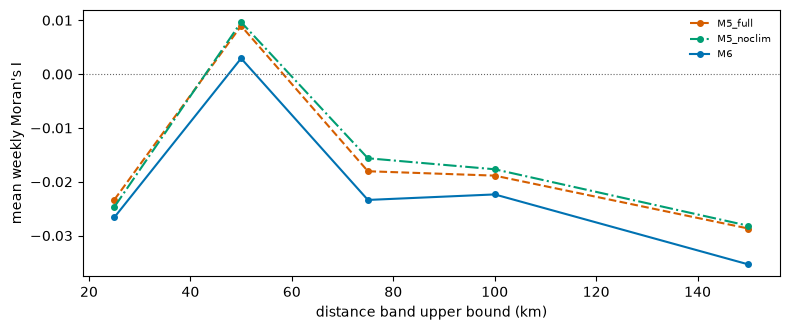

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.4))
CLR = {"M5_full": "#D55E00", "M5_noclim": "#009E73", "M6": "#0072B2"}
LS = {"M5_full": "--", "M5_noclim": "-.", "M6": "-"}
for k in RES:
    s = mor[(mor.model == k) & (mor.hi > 0)]
    ax.plot(s.hi, s.I, marker="o", ms=4, color=CLR[k], ls=LS[k], label=k)
ax.axhline(0, color="#666", ls=":", lw=.8)
ax.set_xlabel("distance band upper bound (km)"); ax.set_ylabel("mean weekly Moran's I")
ax.legend(fontsize=7, frameon=False)
plt.tight_layout()

prim = mor[(mor.model == "M5_full") & (mor.hi > 0)]
sig = prim[prim.p_perm < 0.05]
RANGE_KM = int(sig.hi.max()) if len(sig) else 0
print(f"M5_full: bands with permutation p < 0.05 -> up to {RANGE_KM} km")

## 4 · Empirical variogram

The second estimator §4.1 names, computed on the same residuals: mean squared difference between
district pairs against their separation. A variogram that rises and then flattens has a range at the
flattening point; one that is flat from the start indicates no spatial structure to buffer against.

model    M5_full  M5_noclim      M6
lo  hi                             
0   25    0.1638     0.1642  0.1800
25  50    0.1513     0.1524  0.1692
50  75    0.1603     0.1630  0.1843
75  100   0.1610     0.1633  0.1846
100 150   0.1520     0.1557  0.1794
150 400   0.1493     0.1562  0.1820


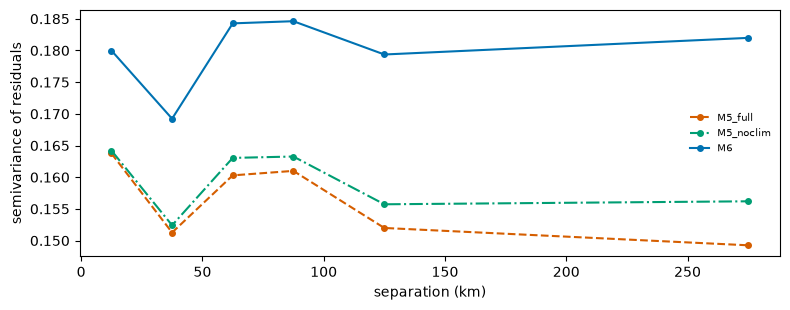

In [5]:
EDGES = [0, 25, 50, 75, 100, 150, 400]
iu = np.triu_indices(len(IDS), k=1)
vg = []
for k, X in wide.items():
    dif = np.nanmean([(row[:, None] - row[None, :]) ** 2 for row in X], axis=0)
    for lo, hi in zip(EDGES[:-1], EDGES[1:]):
        sel = (D[iu] > lo) & (D[iu] <= hi) if lo > 0 else (D[iu] <= hi)
        if sel.sum():
            vg.append(dict(model=k, lo=lo, hi=hi, n_pairs=int(sel.sum()),
                           semivariance=float(dif[iu][sel].mean() / 2)))
vg = pd.DataFrame(vg)
print(vg.pivot_table(index=["lo", "hi"], columns="model", values="semivariance").round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 3.2))
for k in RES:
    s = vg[vg.model == k]
    ax.plot((s.lo + s.hi) / 2, s.semivariance, marker="o", ms=4, color=CLR[k], ls=LS[k], label=k)
ax.set_xlabel("separation (km)"); ax.set_ylabel("semivariance of residuals")
ax.legend(fontsize=7, frameon=False)
plt.tight_layout()

## 5 · Read off the radius and select the fold set

In [6]:
sel = power[power.buffer == f"km_{RANGE_KM}"] if f"km_{RANGE_KM}" in set(power.buffer) else None
if sel is None:
    cands = sorted(int(b.split("_")[1]) for b in power.buffer if b.startswith("km_"))
    RANGE_KM = min([c for c in cands if c >= RANGE_KM], default=cands[-1])
    sel = power[power.buffer == f"km_{RANGE_KM}"]

print(f"selected buffer radius: {RANGE_KM} km\n")
print(sel.to_string(index=False))
print(f"\nfold set: wp4_loocv_folds_srilanka_v1.csv, buffer == 'km_{RANGE_KM}'")
print(f"training districts: {int(sel.train_units_median.iloc[0])} median, "
      f"{int(sel.train_units_min.iloc[0])} worst, of 25")

selected buffer radius: 0 km

buffer  train_units_median  train_units_min  buffered_median  buffered_max  train_unitweeks_median  retained_pct  degenerate_folds
  km_0                  21               16                4             9                    5481          84.0                 0

fold set: wp4_loocv_folds_srilanka_v1.csv, buffer == 'km_0'
training districts: 21 median, 16 worst, of 25


In [7]:
prov = {
    "notebook": "wp4_01_autocorrelation_range",
    "workpackage": "WP4 / section 4.1",
    "country": "sri_lanka",
    "seed": SEED,
    "status": "FIRST ESTIMATE — uses M5-full as frozen; re-run if the registered reference model differs",
    "residuals": {"source": "raw (un-recalibrated) probabilities on the 3,926 frozen test rows",
                  "models": list(RES)},
    "morans_i": {"method": "per-week Moran's I on 26 district residuals, averaged over 151 weeks",
                 "weights": "binary, boundary distance band, equal-area",
                 "significance": f"permutation, {NPERM} shuffles, seed {SEED}",
                 "table": mor.to_dict(orient="records")},
    "variogram": vg.to_dict(orient="records"),
    "selected_radius_km": int(RANGE_KM),
    "selected_fold_set": f"km_{RANGE_KM}",
    "power_at_selected": sel.to_dict(orient="records")[0],
    "inputs": {"wp4_00": prov4["outputs"]},
}
(QUAR / "wp4_01_provenance.json").write_text(json.dumps(prov, indent=2, default=str))
mor.to_csv(QUAR / "wp4_morans_i_srilanka_v1.csv", index=False)
vg.to_csv(QUAR / "wp4_variogram_srilanka_v1.csv", index=False)
print(json.dumps({k: prov[k] for k in ("status", "selected_radius_km", "selected_fold_set")}, indent=2))

{
  "status": "FIRST ESTIMATE \u2014 uses M5-full as frozen; re-run if the registered reference model differs",
  "selected_radius_km": 0,
  "selected_fold_set": "km_0"
}


---

### Design notes carried forward

**This is a first estimate.** §4.1 specifies the reference model's residuals; M5-full as frozen is the
closest available and is used as primary. If the registered reference model differs, re-run — nothing
in the machinery changes, only which residual column is read.

**Weekly replication is what makes n = 26 workable.** Moran's I on a single district-mean residual map
would rest on 26 points. Computing it per week and averaging over 151 weeks uses the temporal
replication the panel already has, and the permutation null is built the same way, so the test and
the statistic are consistent.

**A short range is a real result, not a failure.** If residual correlation dies out inside the first
band, the buffered scheme costs little power and the spatial-CV check is cheap — which is itself
worth reporting, because the reviewer concern that motivated WP4 is then answered directly rather
than by an expensive scheme.

**The power cost of the selected radius is already in `wp4_00`'s table**, so the design can go to the
PI as a single row: this radius, this many training districts in the median and worst fold. Per §4.6
Sri Lanka remains the compact-country companion regardless of what that row says.